# **Image Assignment ADNE: EDA**
#### By Guillermo Velasco, David Fernández-Madera y Rafael de Bloteau

​The NKS_EYE_DISEASE_CLASSIFICATION dataset, hosted on Hugging Face, is designed for the classification of eye diseases using medical images. It comprises a collection of labeled images, each associated with a specific eye condition, facilitating the development and evaluation of machine learning models in ophthalmology. This dataset is particularly useful for tasks such as image classification and model training

### Libraries

In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
import cv2
from datasets import load_dataset
import io
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
import os
from PIL import Image
import io
from sklearn.utils import shuffle
from collections import Counter


### Load dataframe

Here we load the dataframe from the hugging face API using the datasets library.

In [ ]:
# Carga el dataset desde Hugging Face
dataset = load_dataset("nks9/NKS_EYE_DISEASE_CLASSIFICATION", split="train")

# Convierte el dataset a un DataFrame de pandas
df = dataset.to_pandas()

# Muestra las primeras filas del DataFrame
print(df.head())

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


                                               image  label
0  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      1
1  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      3
2  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
3  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0
4  {'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...      0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3795 entries, 0 to 3794
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   image   3795 non-null   object
 1   label   3795 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 59.4+ KB


### Class balance in dataframe

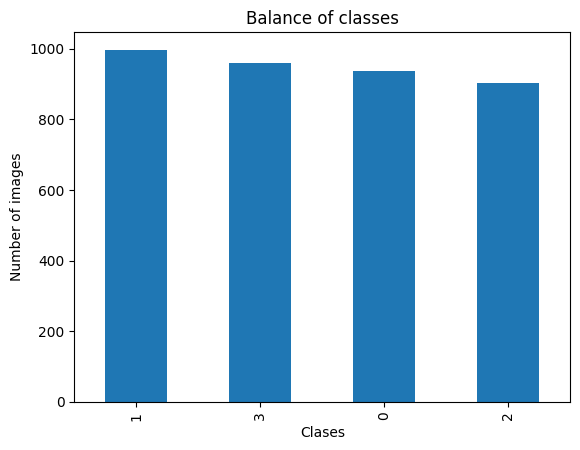

In [ ]:
# Mostrar gráfico de barras del balance de clases
df['label'].value_counts().plot(kind='bar', title='Balance of classes', xlabel='Clases', ylabel='Number of images')
plt.show()

image_sizes = []
image_modes = []

# Recorremos los primeros 100 ejemplos
for img_dict in df['image']:
    if img_dict['bytes'] is not None:
        img = Image.open(io.BytesIO(img_dict['bytes']))
        image_sizes.append(img.size)
        image_modes.append(img.mode)

The class distribution in the dataframe is well balanced across all categories, so no changes or manipulations were necessary

### Most common image sizes, color modes and some other image information

In [ ]:
image_sizes = []
image_modes = []

# Recorremos las imágenes del DataFrame
for img_dict in df['image']:
    img = Image.open(io.BytesIO(img_dict['bytes']))
    image_sizes.append(img.size)   # (width, height)
    image_modes.append(img.mode)   # Ej: 'RGB', 'L', etc.

# Mostramos los resultados más comunes
print("Most common image sizes:", Counter(image_sizes).most_common(5))
print("Color modes:", Counter(image_modes))


Most common image sizes: [((512, 512), 2493), ((256, 256), 1118), ((2592, 1728), 140), ((2464, 1632), 36), ((1848, 1224), 8)]
Color modes: Counter({'RGB': 3795})


- **Most Common Image Sizes**: The dataset contains images of varying sizes, with the following being the most common dimensions:
  - **(512, 512)**: 2493 images (the largest group of images)
  - **(256, 256)**: 1118 images
  - **(2592, 1728)**: 140 images
  - **(2464, 1632)**: 36 images
  - **(1848, 1224)**: 8 images

  This indicates that the dataset includes images with different resolutions, with the majority being either 512x512 or 256x256 in size. The remaining images have larger dimensions, which may require resizing or cropping for uniformity during model training.

- **Color Modes**:
  - The dataset consists predominantly of RGB images, with **3795 images** in RGB format, making it a color image dataset.
  - RGB format indicates that each image contains three channels (Red, Green, and Blue), which is common for most color images.

This information gives insight into the diversity and structure of the dataset, and it will help in deciding how to preprocess and standardize the images (e.g., resizing all images to the same dimensions or ensuring that all images are in RGB format).









In [ ]:
image_info = []

for img_dict in df['image']:
    try:
        byte_data = img_dict['bytes']
        img = Image.open(io.BytesIO(byte_data))

        width, height = img.size
        mode = img.mode
        format_ = img.format or "unknown"
        aspect_ratio = width / height
        num_channels = len(img.getbands())  # Ej: R,G,B => 3
        size_in_kb = len(byte_data) / 1024  # Tamaño en KB

        # Media de color por canal
        arr = np.array(img.convert('RGB')) / 255.0
        r_mean = np.mean(arr[:, :, 0])
        g_mean = np.mean(arr[:, :, 1])
        b_mean = np.mean(arr[:, :, 2])

        image_info.append({
            'size': (width, height),
            'area': width * height,
            'aspect_ratio': round(aspect_ratio, 2),
            'mode': mode,
            'format': format_,
            'channels': num_channels,
            'size_kb': round(size_in_kb, 2),
            'r_mean': round(r_mean, 3),
            'g_mean': round(g_mean, 3),
            'b_mean': round(b_mean, 3),
        })

    except Exception as e:
        print("Error con imagen:", e)


In [ ]:
info_df = pd.DataFrame(image_info)
print(info_df.describe(include='all'))


              size          area  aspect_ratio  mode format  channels  \
count         3795  3.795000e+03   3795.000000  3795   3795    3795.0   
unique           5           NaN           NaN     1      2       NaN   
top     (512, 512)           NaN           NaN   RGB   JPEG       NaN   
freq          2493           NaN           NaN  3795   3611       NaN   
mean           NaN  3.996605e+05      1.024358   NaN    NaN       3.0   
std            NaN  8.894610e+05      0.107926   NaN    NaN       0.0   
min            NaN  6.553600e+04      1.000000   NaN    NaN       3.0   
25%            NaN  6.553600e+04      1.000000   NaN    NaN       3.0   
50%            NaN  2.621440e+05      1.000000   NaN    NaN       3.0   
75%            NaN  2.621440e+05      1.000000   NaN    NaN       3.0   
max            NaN  4.478976e+06      1.510000   NaN    NaN       3.0   

            size_kb       r_mean       g_mean       b_mean  
count   3795.000000  3795.000000  3795.000000  3795.000000  
u


This summary provides key statistics about the image dataset, including their size, color channel properties, and some of the basic color statistics.

#### **General Statistics:**

- **Total Images (count)**: 3795 images in the dataset.
  
- **Most Common Image Size**:
  - The most frequent image size is **(512, 512)**, which is present in **2493 images**.
  
- **Image Area (mean)**: The average area of the images is approximately **399,660 pixels** (with a significant variation in size as seen in the standard deviation).

- **Aspect Ratio**: The aspect ratio of the images is mostly **1.0**, which indicates that the width and height of the images are almost equal. This is typical for most images in square formats like **512x512**.

- **Color Mode**: All images in the dataset are in **RGB** mode (3 color channels).

- **File Format**: Most of the images are in the **JPEG** format, as indicated by a frequency of **3611 occurrences**.

#### **Channel and Size Information:**

- **Size (KB)**:
  - Image size ranges from a minimum of **3.7 KB** to a maximum of **3394.33 KB**, with an average of **181.51 KB**.
  
- **Mean Color Values**:
  - **Red Channel (r_mean)**: The average mean value of the red channel across all images is **0.4197**.
  - **Green Channel (g_mean)**: The mean for the green channel is **0.2792**.
  - **Blue Channel (b_mean)**: The mean for the blue channel is **0.1711**.
  
  These values indicate that the images generally have a stronger red channel, with less emphasis on green and blue.
  
  In photos of eyes, it's common to see a stronger emphasis on the red channel, which is often due to factors like natural skin tones around the eyes, blood vessels in the sclera (the white part of the eye), and the lighting conditions. Skin tones typically have more red wavelengths, which leads to a higher intensity in the red channel. Additionally, lighting conditions—such as natural light or indoor lighting—often emphasize red hues. The green and blue channels are generally less pronounced, as natural eye and skin colors don't typically contain much green or blue

#### **Other Notable Insights**:

- **Aspect Ratio**: With most images having an aspect ratio close to **1.0**, it suggests that the dataset contains mostly square-shaped images (especially the common size of 512x512). However, there are some variations, especially with the inclusion of a few images with very high resolutions.
  
- **Pixel Intensity Distribution**:
  - The **Red channel** has a relatively high mean compared to the **Green** and **Blue** channels, suggesting a dominance of red tones in the image dataset.
  - The **standard deviation** of the mean color values is also noteworthy, as it reflects some variation in color across the dataset, with the **red channel** showing the most variation.

This information is important for preprocessing tasks such as normalization, resizing, or analyzing the overall distribution of colors across the dataset.


### RGB Histogram (one image)

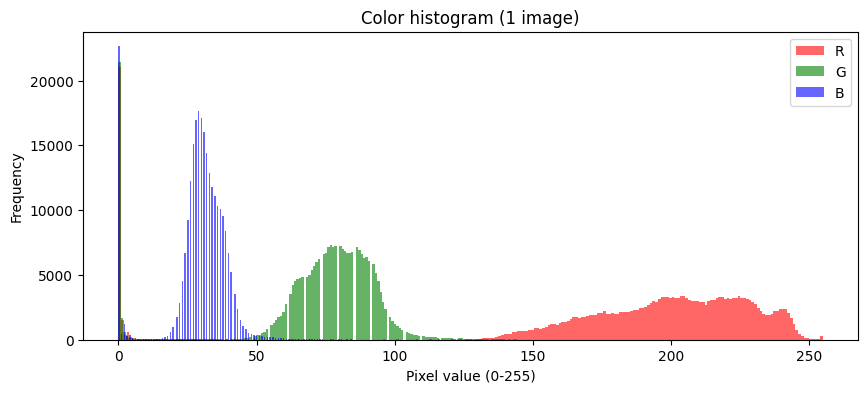

In [ ]:
def plot_color_histogram(img_dict):
    # Convertir bytes a imagen PIL
    img = Image.open(io.BytesIO(img_dict['bytes'])).convert('RGB')
    arr = np.array(img)  # Convertir a array NumPy (H, W, 3)

    plt.figure(figsize=(10, 4))
    for i, color in enumerate(['r', 'g', 'b']):
        plt.hist(arr[:, :, i].flatten(), bins=256, color=color, alpha=0.6, label=color.upper())

    plt.title("Color histogram (1 image)")
    plt.xlabel("Pixel value (0-255)")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

# Usar una imagen del dataset
plot_color_histogram(df['image'].iloc[0])


As explained before, we can see the much higher pixel value for red (a strong presence of red tones) compared with blue and green. A spike at pixel value 0 across all channels suggests that the image has many completely black pixels (which is typical for backgrounds).



### Pixel Value Distribution (Across Different Images)

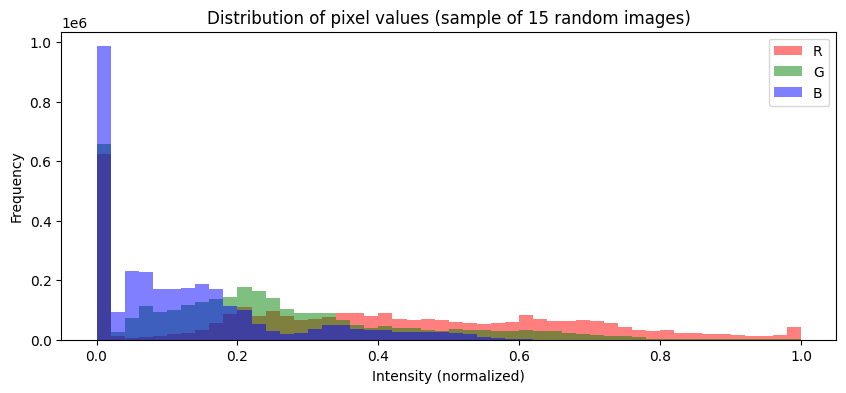

In [ ]:
import random

def get_pixel_statistics(images, sample_size=1):
    r_vals, g_vals, b_vals = [], [], []

    # Seleccionar imágenes aleatorias
    sampled_images = random.sample(images, min(sample_size, len(images)))

    for img_dict in sampled_images:
        img = Image.open(io.BytesIO(img_dict['bytes'])).convert('RGB')
        arr = np.array(img) / 255.0  # Normalizado entre 0 y 1

        r_vals.extend(arr[:, :, 0].flatten())
        g_vals.extend(arr[:, :, 1].flatten())
        b_vals.extend(arr[:, :, 2].flatten())

    return r_vals, g_vals, b_vals

# Obtener imágenes como lista
images = df['image'].tolist()

# Obtener estadísticas de píxeles con imágenes aleatorias
sample_size=15
r, g, b = get_pixel_statistics(images, sample_size=sample_size)

# Graficar distribución
plt.figure(figsize=(10, 4))
plt.hist(r, bins=50, alpha=0.5, color='r', label='R')
plt.hist(g, bins=50, alpha=0.5, color='g', label='G')
plt.hist(b, bins=50, alpha=0.5, color='b', label='B')
plt.title(f"Distribution of pixel values (sample of {sample_size} random images)")
plt.xlabel("Intensity (normalized)")
plt.ylabel("Frequency")
plt.legend()
plt.show()


The main conclusions are the following ones:

- Pixel values normalized between 0.0 (dark) and 1.0 (bright).
- **Red** shows broad distribution with more mid-high intensity.
- **Green** is mostly mid-low intensity.
- **Blue** has a very sharp peak at 0 → many dark or blue-deficient regions.
- Indicates dataset bias towards darker tones and lower blue intensity overall.


### Save all images localy for model training

In [ ]:
# Optional: label mapping (custom names)
label_map = {
    0: "cataract",
    1: "diabetic_retinopathy",
    2: "glaucoma",
    3: "normal"
    # Add more if needed
}

# Shuffle the dataset
df = shuffle(df, random_state=42)

# Get all unique labels
unique_labels = df['label'].unique()

# Loop through each class
for label in unique_labels:
    label_str = label_map[label] if label in label_map else str(label)

    # Subset DataFrame for this class
    class_df = df[df['label'] == label]

    # Split: first 100 for validation, rest for training
    val_df = class_df.iloc[:200]
    train_df = class_df.iloc[200:]

    # Create directories
    os.makedirs(f"train/{label_str}", exist_ok=True)
    os.makedirs(f"val/{label_str}", exist_ok=True)

    # Save training images
    for idx, row in train_df.iterrows():
        image = Image.open(io.BytesIO(row['image']['bytes']))
        if image.mode != "RGB":
            image = image.convert("RGB")
        filename = f"image_{idx}.jpg"
        image.save(os.path.join(f"train/{label_str}", filename))

    # Save validation images
    for idx, row in val_df.iterrows():
        image = Image.open(io.BytesIO(row['image']['bytes']))
        if image.mode != "RGB":
            image = image.convert("RGB")
        filename = f"image_{idx}.jpg"
        image.save(os.path.join(f"val/{label_str}", filename))
